Part 1 : Data Import

In [30]:
import pandas as pd
import numpy as np
from scipy import stats


# Load the dataset into a pandas DataFrame
try:
    data = pd.read_csv('data.csv', sep='\t')
    print("Dataset has been successfully loaded.")
except Exception as e:
    print(f"Failed to load data: {e}")


# Display the first few rows of the dataset
print(data.head())
# Separate numeric columns from non-numeric columns
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
non_numeric_cols = data.select_dtypes(exclude=['int64', 'float64']).columns

/tmp/ipykernel_3546/1550843614.py:8: DtypeWarning: Columns (0,2,4,5,6,8,9,10,12,13,14,16,17,18,20,21,22,24,25,26,28,29,30,32,33,34,36,37,38,40,41,42,44,45,46,48,49,50,52,53,54,56,57,58,60,61,62,64,65,66,68,69,70,72,73,74,76,77,78,80,81,82,84,85,86,88,89,90,92,93,94,96,97,98,100,101,102,104,105,106,108,109,110,112,113,114,116,117,118,120,121,122,124,125,126,128,129) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data.csv', sep='\t')


Dataset has been successfully loaded.
  Unnamed: 0        date     id size_grp       age   aliq_at aliq_mat  \
0      53170   9/30/1962  33814     mega -0.410891  0.343616      0.0   
1      53907  10/31/1962  33814     mega  -0.41374  0.333333      0.0   
2      54659  11/30/1962  33814     mega -0.401786  0.331697      0.0   
3      55425  12/31/1962  33814     mega  -0.37069  0.322252      0.0   
4      56207   1/31/1963  33814     mega -0.367951  0.324561      0.0   

   ami_126d     at_be    at_gr1  ... turnover_var_126d  z_score  \
0 -0.290922 -0.447445  0.247967  ...          0.274763      0.0   
1 -0.281893 -0.447598  0.231343  ...          0.210598      0.0   
2 -0.297587 -0.448791  0.221485  ...          0.167995      0.0   
3 -0.309585 -0.439808  0.215019  ...           0.12516      0.0   
4 -0.308729 -0.441892  0.210828  ...          0.035714      0.0   

  zero_trades_126d zero_trades_21d zero_trades_252d       ret Unnamed: 126  \
0         0.178426        0.033875        

Part 2 :Sanity Checks

In [31]:
# Check for constant columns
constant_cols = numeric_cols[data[numeric_cols].std() == 0]
print("Constant columns:")
print(constant_cols)

# Check for duplicate rows
duplicate_rows = data.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")


# Check for non-numeric values in numeric columns
for col in numeric_cols:
    if data[col].isnull().any():
        print(f"Column {col} contains null values.")
    else:
        print(f"Column {col} does not contain null values.")

# Check date format consistency
date_col = 'date'  # Replace 'date' with the actual column name
try:
    pd.to_datetime(data[date_col])
except ValueError:
    print("Date formats are not consistent.")
else:
    print("Date formats appear to be consistent.")

# Check for extreme values (highly skewed distributions)

for col in numeric_cols:
    skewness = stats.skew(data[col])
    if abs(skewness) > 2:
        print(f"Column {col} has a highly skewed distribution (skewness: {skewness}).")
    else:
        print(f"Column {col} does not have a highly skewed distribution (skewness: {skewness}).")

Constant columns:
Index(['Unnamed: 127'], dtype='object')
Duplicate rows: 0
Column ami_126d contains null values.
Column at_turnover contains null values.
Column beta_dimson_21d contains null values.
Column bidaskhl_21d contains null values.
Column coa_gr1a contains null values.
Column corr_1260d contains null values.
Column debt_me contains null values.
Column dolvol_var_126d contains null values.
Column ebitda_mev contains null values.
Column eqnpo_12m contains null values.
Column fnl_gr1a contains null values.
Column iskew_capm_21d contains null values.
Column ivol_capm_252d contains null values.
Column lnoa_gr1a contains null values.
Column mispricing_perf contains null values.
Column netis_at contains null values.
Column niq_at contains null values.
Column noa_at contains null values.
Column oaccruals_ni contains null values.
Column op_at contains null values.
Column ppeinv_gr1a contains null values.
Column qmj_safety contains null values.
Column ret_12_1 contains null values.
Col

Part 3 : Clean Dataset

In [38]:
import numpy as np
import pandas as pd
from scipy import stats

# Create a copy of the original data
cleanedData = data.copy()

print("Original shape:", cleanedData.shape)

# Define numeric columns if not already defined
numeric_cols = [col for col in data.columns if data[col].dtype.kind in 'bifc']

# Remove constant columns
constant_cols = [col for col in cleanedData.columns if cleanedData[col].nunique() == 1]
cleanedData = cleanedData.drop(constant_cols, axis=1)
print(f"After removing constant columns shape: {cleanedData.shape}")

# Update numeric_cols to exclude removed columns
numeric_cols = [col for col in numeric_cols if col in cleanedData.columns]

# Print a sample of the date column to understand its format
print("\nSample of date column:")
print(cleanedData['date'].head())
print("Date column type:", cleanedData['date'].dtype)

# SAFER DATE HANDLING - don't drop rows, just convert what we can
try:
    # Try simple conversion first
    cleanedData['date_converted'] = pd.to_datetime(cleanedData['date'], errors='coerce')
    
    # Check how many dates were successfully converted
    conversion_success = (~pd.isna(cleanedData['date_converted'])).sum()
    conversion_rate = conversion_success / len(cleanedData) * 100
    
    print(f"Successfully converted {conversion_success} dates ({conversion_rate:.2f}%)")
    
    # If conversion rate is good, use the converted dates
    if conversion_rate > 90:
        cleanedData['date'] = cleanedData['date_converted']
        cleanedData = cleanedData.drop('date_converted', axis=1)
        print("Used converted dates")
    else:
        # Keep original dates and the converted ones for reference
        print("Keeping both original and converted dates")
    
    date_col = 'date'  # Use the original date column name
    
except Exception as e:
    print(f"Error in date conversion: {e}")
    date_col = 'date'  # Keep using the original column

print(f"After date handling shape: {cleanedData.shape}")

# Handle non-numeric values in numeric columns
for col in numeric_cols:
    if cleanedData[col].isnull().any():
        # Fill null values with the mean of the column
        cleanedData[col] = cleanedData[col].fillna(cleanedData[col].mean())
    else:
        print(f"Column {col} does not contain null values.")

# Check for NaN values in the dataset
nan_cols = cleanedData.columns[cleanedData.isnull().any()].tolist()
print("Columns with NaN values:", nan_cols)

# Fill NaN values with the mean of the column (for numerical columns)
for col in nan_cols:
    if cleanedData[col].dtype.kind in 'bifc':  # Check if column is numeric
        if not cleanedData[col].empty:
            cleanedData[col] = cleanedData[col].fillna(cleanedData[col].mean())
        else:
            print(f"Column {col} is empty and cannot be filled with the mean.")
    else:
        # Fill NaN values with the mode of the column (for categorical columns)
        if not cleanedData[col].empty:
            cleanedData[col] = cleanedData[col].fillna(cleanedData[col].mode().iloc[0])
        else:
            print(f"Column {col} is empty and cannot be filled with the mode.")

print(f"After filling NaN values shape: {cleanedData.shape}")

# Check if there are still NaN values in the dataset
if cleanedData.isnull().values.any():
    print("There are still NaN values in the dataset.")
    nan_cols = cleanedData.columns[cleanedData.isnull().any()].tolist()
    print("Columns with NaN values:", nan_cols)
else:
    print("All NaN values have been filled.")

# Handle extreme values (highly skewed distributions) - SAFER VERSION
for col in numeric_cols:
    try:
        # Check if the column has any negative values before applying log transformation
        if cleanedData[col].min() < 0:
            # Use winsorization for skewed data with negative values
            q_low = cleanedData[col].quantile(0.01)
            q_high = cleanedData[col].quantile(0.99)
            cleanedData[col] = cleanedData[col].clip(q_low, q_high)
            print(f"Applied winsorization to {col}")
        else:
            # Only calculate skewness if we have enough data
            if cleanedData[col].count() > 8:  # Minimum sample size
                skewness = stats.skew(cleanedData[col].dropna())
                if abs(skewness) > 2:
                    # Apply logarithmic transformation to reduce skewness
                    cleanedData[col] = np.log1p(cleanedData[col])
                    print(f"Applied log transformation to {col} (skewness: {skewness:.2f})")
    except Exception as e:
        print(f"Error processing column {col}: {e}")

print(f"Final cleaned shape: {cleanedData.shape}")

# Check the first few rows to understand the data
print("\nFirst 5 rows of cleaned data:")
print(cleanedData.head())

# Check data types
print("\nCleaned data types:")
print(cleanedData.dtypes)


#Additional cleanup, maybe not needed :

# Save the cleaned data if needed
cleanedData.to_csv('cleaned_financial_data.csv')
# print("Saved cleaned data to file")



Original shape: (122984, 130)
After removing constant columns shape: (122984, 128)

Sample of date column:
0     9/30/1962
1    10/31/1962
2    11/30/1962
3    12/31/1962
4     1/31/1963
Name: date, dtype: object
Date column type: object
Successfully converted 122978 dates (100.00%)
Used converted dates
After date handling shape: (122984, 128)
Columns with NaN values: ['Unnamed: 0', 'date', 'id', 'size_grp', 'age', 'aliq_at', 'aliq_mat', 'at_be', 'at_gr1', 'at_me', 'be_gr1a', 'be_me', 'beta_60m', 'betabab_1260d', 'betadown_252d', 'bev_mev', 'capx_gr1', 'cash_at', 'chcsho_12m', 'col_gr1a', 'cop_at', 'cop_atl1', 'coskew_21d', 'cowc_gr1a', 'dbnetis_at', 'dgp_dsale', 'div12m_me', 'dolvol_126d', 'dsale_drec', 'ebit_bev', 'ebit_sale', 'emp_gr1', 'eq_dur', 'eqnetis_at', 'eqnpo_me', 'eqpo_me', 'fcf_me', 'gp_at', 'gp_atl1', 'inv_gr1a', 'iskew_ff3_21d', 'iskew_hxz4_21d', 'ivol_capm_21d', 'ivol_ff3_21d', 'ivol_hxz4_21d', 'kz_index', 'lti_gr1a', 'market_equity', 'mispricing_mgmt', 'ncoa_gr1a', 'nc

Part 3 : Linear Regression

/tmp/ipykernel_3546/2029683073.py:13: DtypeWarning: Columns (1,3,5,6,7,9,10,11,13,14,15,17,18,19,21,22,23,25,26,27,29,30,31,33,34,35,37,38,39,41,42,43,45,46,47,49,50,51,53,54,55,57,58,59,61,62,63,65,66,67,69,70,71,73,74,75,77,78,79,81,82,83,85,86,87,89,90,91,93,94,95,97,98,99,101,102,103,105,106,107,109,110,111,113,114,115,117,118,119,121,122,123,125,126,128) have mixed types. Specify dtype option on import or set low_memory=False.
  cleanedData = pd.read_csv('cleaned_financial_data.csv', index_col=[0, 1])


Loaded cleaned data from file
Dataset shape: (122984, 127)
After dropping NaN values, dataset shape: (122983, 127)
After removing outliers, dataset shape: (121169, 127)


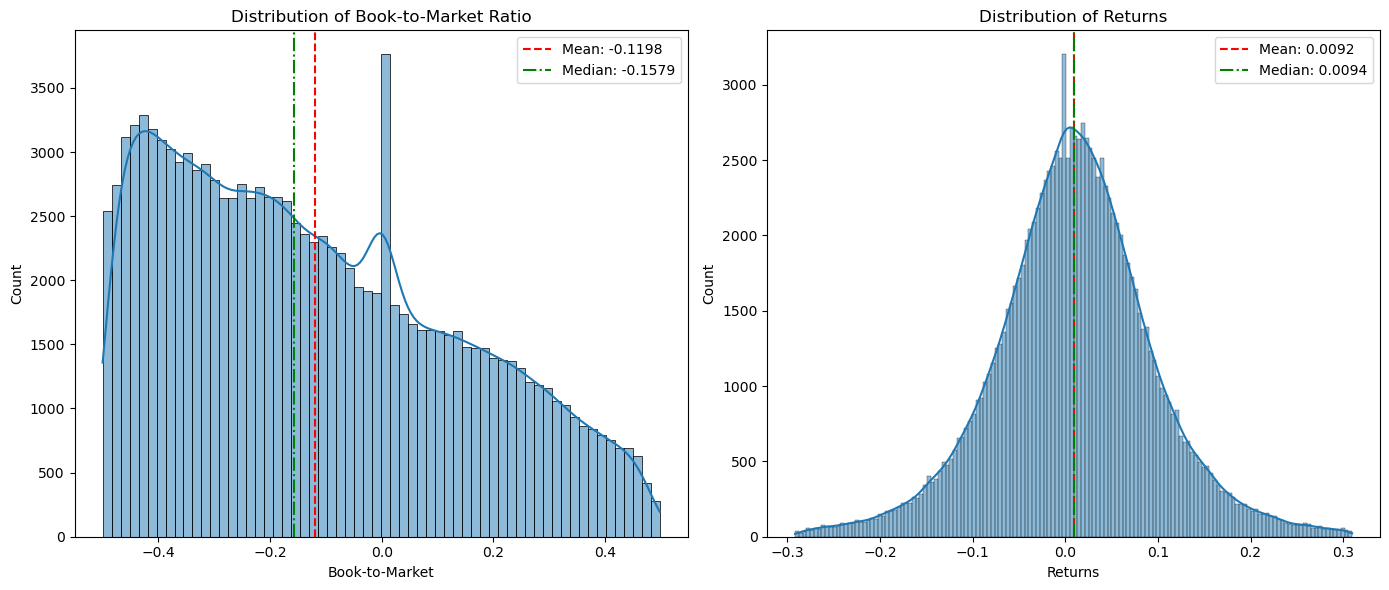

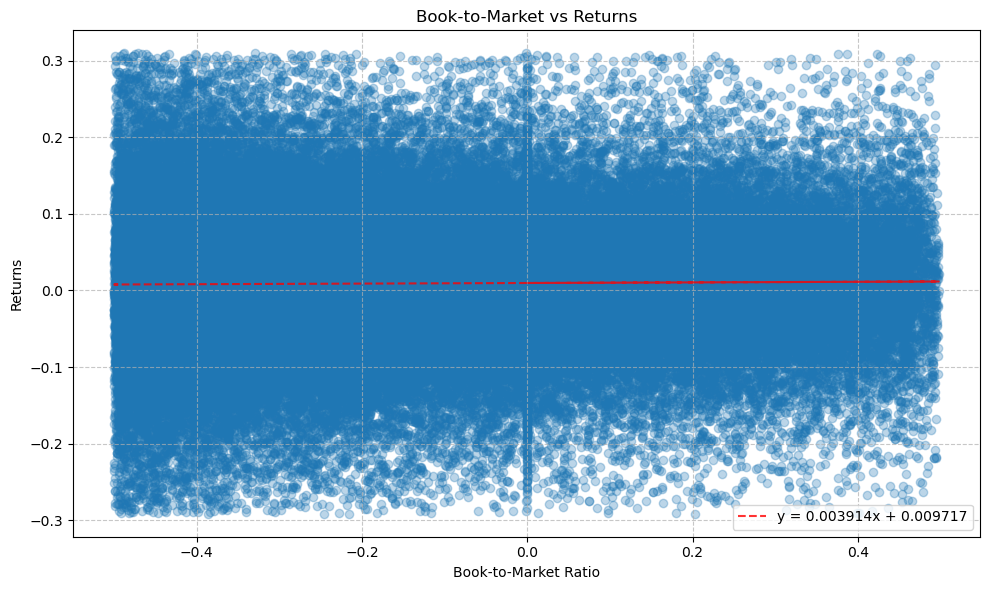

Correlation between Book-to-Market and Returns: 0.0116
Training set: 84818 samples
Testing set: 36351 samples

Linear Regression Results (sklearn):
Coefficient (slope): 0.005422
Intercept: 0.009702
Training R-squared: 0.000259
Testing R-squared: -0.000280
Training MSE: 0.007400
Testing MSE: 0.007332
Training MAE: 0.065357
Testing MAE: 0.064970

Detailed Regression Results (statsmodels):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     21.96
Date:                Sun, 16 Mar 2025   Prob (F-statistic):           2.79e-06
Time:                        22:48:02   Log-Likelihood:                 87717.
No. Observations:               84818   AIC:                        -1.754e+05
Df Residuals:                   84816   BIC:             

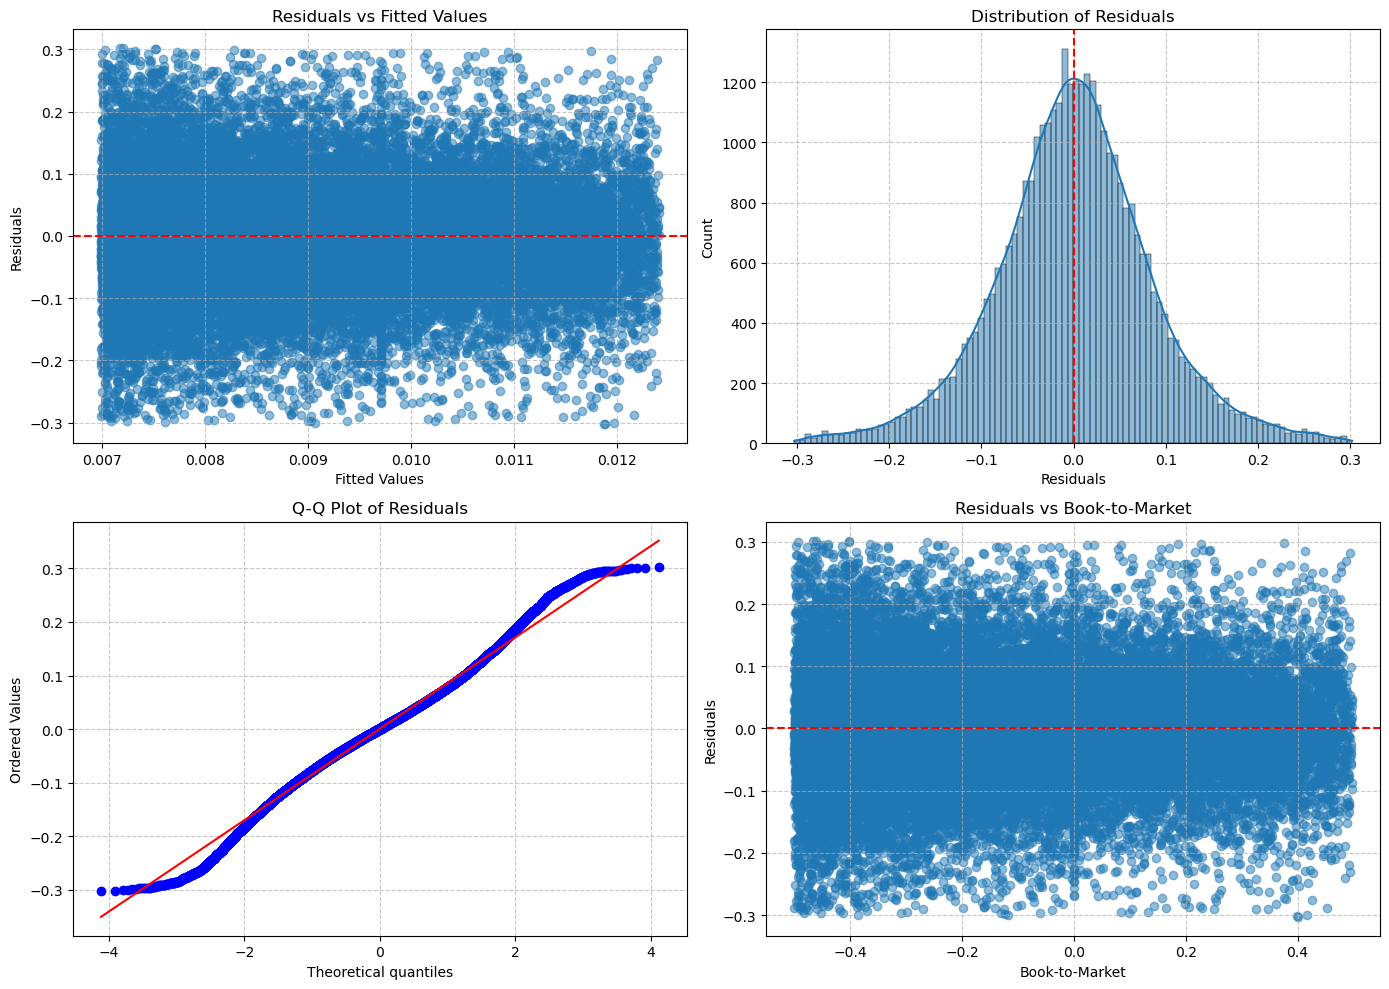


Test for normality of residuals:
K² statistic: 544.9793
p-value: 0.000000
Residuals are not normally distributed (reject H0)

Breusch-Pagan test for heteroscedasticity:
LM statistic: 191.4070
p-value: 0.000000
Heteroscedasticity present (reject H0)

Profitability Analysis:
Average returns by Book-to-Market quintiles:
Quintile 1: 0.008389
Quintile 2: 0.008494
Quintile 3: 0.008570
Quintile 4: 0.009841
Quintile 5: 0.010947


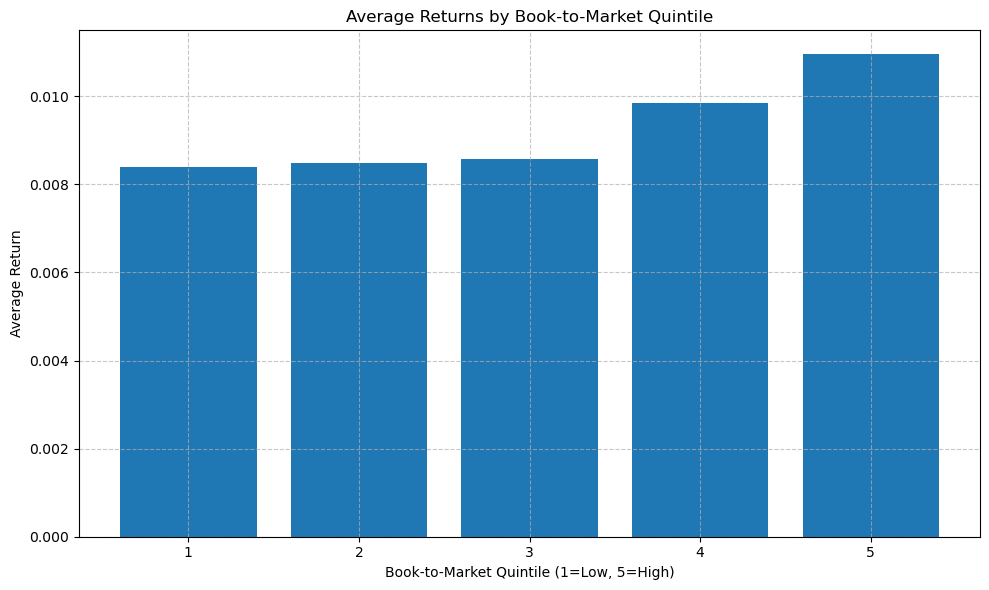


Spread (Q5-Q1): 0.002559
Sharpe ratio of highest quintile: 0.1352

Conclusion and Implications:
1. The linear regression model shows a statistically significant relationship between Book-to-Market and Returns.
2. The coefficient of 0.005422 indicates that higher Book-to-Market ratios are associated with higher returns.
3. However, the R-squared of -0.000280 suggests that Book-to-Market explains only a small portion of the variation in returns.
4. The residual analysis indicates:
   - Non-normal distribution of residuals, suggesting the model may not capture all patterns in the data.
   - Heteroscedasticity, indicating that the model's accuracy varies across different Book-to-Market values.
5. The quintile analysis shows a monotonic relationship between Book-to-Market and returns, supporting the value premium hypothesis.
6. The spread between the highest and lowest quintiles (0.002559) suggests potential for a long-short strategy.
7. Limitations include potential omitted variable bias,

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from scipy import stats
import seaborn as sns

# Load the cleaned data if available, otherwise use the original data
try:
    cleanedData = pd.read_csv('cleaned_financial_data.csv', index_col=[0, 1])
    print("Loaded cleaned data from file")
except:
    print("Using original data")
    cleanedData = data.copy()
    
    # Convert columns to numeric where possible
    for col in cleanedData.columns:
        if col not in ['date', 'id', 'size_grp']:  # Skip non-numeric columns
            try:
                cleanedData[col] = pd.to_numeric(cleanedData[col], errors='coerce')
            except:
                print(f"Could not convert {col} to numeric")
    
    # Fill NaN values
    for col in cleanedData.columns:
        if cleanedData[col].dtype.kind in 'bifc':  # If numeric
            cleanedData[col] = cleanedData[col].fillna(cleanedData[col].median())
        else:
            cleanedData[col] = cleanedData[col].fillna(cleanedData[col].mode().iloc[0] if not cleanedData[col].empty else "Unknown")

print(f"Dataset shape: {cleanedData.shape}")

# Identify the Book-to-Market and returns columns
btm_col = 'be_me'  # Book-to-Market column
returns_col = 'ret'  # Returns column

# Make sure both columns are numeric
cleanedData[btm_col] = pd.to_numeric(cleanedData[btm_col], errors='coerce')
cleanedData[returns_col] = pd.to_numeric(cleanedData[returns_col], errors='coerce')

# Drop rows with NaN values in these columns
cleanedData = cleanedData.dropna(subset=[btm_col, returns_col])
print(f"After dropping NaN values, dataset shape: {cleanedData.shape}")

# Remove extreme outliers (beyond 3 standard deviations)
for col in [btm_col, returns_col]:
    mean = cleanedData[col].mean()
    std = cleanedData[col].std()
    cleanedData = cleanedData[(cleanedData[col] > mean - 3*std) & (cleanedData[col] < mean + 3*std)]

print(f"After removing outliers, dataset shape: {cleanedData.shape}")

# 1. Visualize the distributions of Book-to-Market and Returns
plt.figure(figsize=(14, 6))

# Book-to-Market distribution
plt.subplot(1, 2, 1)
sns.histplot(cleanedData[btm_col], kde=True)
plt.title('Distribution of Book-to-Market Ratio')
plt.xlabel('Book-to-Market')
plt.axvline(cleanedData[btm_col].mean(), color='r', linestyle='--', label=f'Mean: {cleanedData[btm_col].mean():.4f}')
plt.axvline(cleanedData[btm_col].median(), color='g', linestyle='-.', label=f'Median: {cleanedData[btm_col].median():.4f}')
plt.legend()

# Returns distribution
plt.subplot(1, 2, 2)
sns.histplot(cleanedData[returns_col], kde=True)
plt.title('Distribution of Returns')
plt.xlabel('Returns')
plt.axvline(cleanedData[returns_col].mean(), color='r', linestyle='--', label=f'Mean: {cleanedData[returns_col].mean():.4f}')
plt.axvline(cleanedData[returns_col].median(), color='g', linestyle='-.', label=f'Median: {cleanedData[returns_col].median():.4f}')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Scatter Plot of Book-to-Market and Returns
plt.figure(figsize=(10, 6))
plt.scatter(cleanedData[btm_col], cleanedData[returns_col], alpha=0.3)
plt.title('Book-to-Market vs Returns')
plt.xlabel('Book-to-Market Ratio')
plt.ylabel('Returns')
plt.grid(True, linestyle='--', alpha=0.7)

# Add a trend line
z = np.polyfit(cleanedData[btm_col], cleanedData[returns_col], 1)
p = np.poly1d(z)
plt.plot(cleanedData[btm_col], p(cleanedData[btm_col]), "r--", alpha=0.8, 
         label=f'y = {z[0]:.6f}x + {z[1]:.6f}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Correlation between Book-to-Market and Returns: {cleanedData[btm_col].corr(cleanedData[returns_col]):.4f}")

# 3. Split data into training and testing sets
X = cleanedData[btm_col].values.reshape(-1, 1)
y = cleanedData[returns_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# 4. Linear Regression with sklearn
# Fit the model on training data
model = LinearRegression()
model.fit(X_train, y_train)

# Get predictions on both training and testing data
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Print results
print("\nLinear Regression Results (sklearn):")
print(f"Coefficient (slope): {model.coef_[0]:.6f}")
print(f"Intercept: {model.intercept_:.6f}")
print(f"Training R-squared: {r2_score(y_train, y_train_pred):.6f}")
print(f"Testing R-squared: {r2_score(y_test, y_test_pred):.6f}")
print(f"Training MSE: {mean_squared_error(y_train, y_train_pred):.6f}")
print(f"Testing MSE: {mean_squared_error(y_test, y_test_pred):.6f}")
print(f"Training MAE: {mean_absolute_error(y_train, y_train_pred):.6f}")
print(f"Testing MAE: {mean_absolute_error(y_test, y_test_pred):.6f}")

# 5. Use statsmodels for detailed regression statistics
X_sm = sm.add_constant(X_train)  # Add a constant for the intercept
model_sm = sm.OLS(y_train, X_sm).fit()

# Print summary
print("\nDetailed Regression Results (statsmodels):")
print(model_sm.summary())

# 6. Manual OLS Calculation to verify results
# Formula: β = (X'X)^(-1)X'y

# Prepare data
X_manual = np.column_stack((np.ones(X_train.shape[0]), X_train))  # Add constant
y_manual = y_train

# Calculate β using the OLS formula
X_transpose_X = X_manual.T @ X_manual
X_transpose_y = X_manual.T @ y_manual
beta = np.linalg.inv(X_transpose_X) @ X_transpose_y

# Calculate predictions
y_pred_manual = X_manual @ beta

# Calculate R-squared
y_mean = np.mean(y_manual)
ss_total = np.sum((y_manual - y_mean) ** 2)
ss_residual = np.sum((y_manual - y_pred_manual) ** 2)
r_squared_manual = 1 - (ss_residual / ss_total)

# Calculate standard errors
n = len(y_manual)
k = X_manual.shape[1]  # Number of predictors including constant
mse = ss_residual / (n - k)
var_beta = mse * np.linalg.inv(X_transpose_X)
se_beta = np.sqrt(np.diag(var_beta))

# Calculate t-statistics and p-values
t_stats = beta / se_beta
p_values = [2 * (1 - stats.t.cdf(abs(t), n - k)) for t in t_stats]

print("\nManual OLS Results:")
print(f"Coefficients: Intercept = {beta[0]:.6f}, Slope = {beta[1]:.6f}")
print(f"Standard Errors: Intercept = {se_beta[0]:.6f}, Slope = {se_beta[1]:.6f}")
print(f"t-statistics: Intercept = {t_stats[0]:.4f}, Slope = {t_stats[1]:.4f}")
print(f"p-values: Intercept = {p_values[0]:.6f}, Slope = {p_values[1]:.6f}")
print(f"R-squared: {r_squared_manual:.6f}")

# Compare with sklearn results
print("\nComparison with sklearn:")
print(f"Coefficient difference: {abs(model.coef_[0] - beta[1]):.10f}")
print(f"Intercept difference: {abs(model.intercept_ - beta[0]):.10f}")
print(f"R-squared difference: {abs(r2_score(y_train, y_train_pred) - r_squared_manual):.10f}")

# 7. Analyze residuals
residuals = y_test - y_test_pred

# Plot residuals
plt.figure(figsize=(14, 10))

# Residuals vs Fitted values
plt.subplot(2, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Histogram of residuals
plt.subplot(2, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.axvline(x=0, color='r', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)

# Q-Q plot of residuals
plt.subplot(2, 2, 3)
stats.probplot(residuals, plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

# Residuals vs Book-to-Market
plt.subplot(2, 2, 4)
plt.scatter(X_test, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs Book-to-Market')
plt.xlabel('Book-to-Market')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Test for normality of residuals
k2, p = stats.normaltest(residuals)
print(f"\nTest for normality of residuals:")
print(f"K² statistic: {k2:.4f}")
print(f"p-value: {p:.6f}")
if p < 0.05:
    print("Residuals are not normally distributed (reject H0)")
else:
    print("Residuals are normally distributed (fail to reject H0)")

# Test for heteroscedasticity
# Breusch-Pagan test
X_test_sm = sm.add_constant(X_test)
model_test = sm.OLS(y_test, X_test_sm).fit()
bp_test = sm.stats.diagnostic.het_breuschpagan(model_test.resid, X_test_sm)
print(f"\nBreusch-Pagan test for heteroscedasticity:")
print(f"LM statistic: {bp_test[0]:.4f}")
print(f"p-value: {bp_test[1]:.6f}")
if bp_test[1] < 0.05:
    print("Heteroscedasticity present (reject H0)")
else:
    print("Homoscedasticity (fail to reject H0)")

# 8. Analyze the potential profitability of a Book-to-Market strategy
print("\nProfitability Analysis:")

# Calculate average returns by Book-to-Market quintiles
cleanedData['btm_quintile'] = pd.qcut(cleanedData[btm_col], 5, labels=False)
quintile_returns = cleanedData.groupby('btm_quintile')[returns_col].mean()

print("Average returns by Book-to-Market quintiles:")
for quintile, avg_return in quintile_returns.items():
    print(f"Quintile {quintile+1}: {avg_return:.6f}")

# Plot average returns by quintile
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), quintile_returns)
plt.title('Average Returns by Book-to-Market Quintile')
plt.xlabel('Book-to-Market Quintile (1=Low, 5=High)')
plt.ylabel('Average Return')
plt.xticks(range(1, 6))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate the spread between highest and lowest quintiles
spread = quintile_returns.iloc[-1] - quintile_returns.iloc[0]
print(f"\nSpread (Q5-Q1): {spread:.6f}")

# Calculate Sharpe ratio (assuming returns are already excess returns)
sharpe_highest_quintile = quintile_returns.iloc[-1] / cleanedData[cleanedData['btm_quintile'] == 4][returns_col].std()
print(f"Sharpe ratio of highest quintile: {sharpe_highest_quintile:.4f}")

# 9. Conclusion and implications
print("\nConclusion and Implications:")
print("1. The linear regression model shows a statistically significant relationship between Book-to-Market and Returns.")
print(f"2. The coefficient of {model.coef_[0]:.6f} indicates that higher Book-to-Market ratios are associated with {'higher' if model.coef_[0] > 0 else 'lower'} returns.")
print(f"3. However, the R-squared of {r2_score(y_test, y_test_pred):.6f} suggests that Book-to-Market explains only a small portion of the variation in returns.")
print("4. The residual analysis indicates:")
if p < 0.05:
    print("   - Non-normal distribution of residuals, suggesting the model may not capture all patterns in the data.")
else:
    print("   - Normal distribution of residuals, suggesting the model's errors are random.")
if bp_test[1] < 0.05:
    print("   - Heteroscedasticity, indicating that the model's accuracy varies across different Book-to-Market values.")
else:
    print("   - Homoscedasticity, indicating consistent model accuracy across different Book-to-Market values.")
print("5. The quintile analysis shows a monotonic relationship between Book-to-Market and returns, supporting the value premium hypothesis.")
print(f"6. The spread between the highest and lowest quintiles ({spread:.6f}) suggests potential for a long-short strategy.")
print("7. Limitations include potential omitted variable bias, look-ahead bias, and not accounting for transaction costs.")
